# Домашнее задание «Алгоритмы кластеризации». Тян Е.В.

## Импорт библиотек

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import skimage
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from skimage.metrics import structural_similarity as ssim

In [3]:
# Вспомогательные функции

def draw_picture(image, title, bgr=True): # Функция из задания, спасибо!
    if bgr:
        b, g, r = cv2.split(image)
        image = cv2.merge([r, g, b])

    plt.figure()
    plt.axis('off')
    plt.title(title)
    plt.imshow(image)

def flat_img(unflattened_img):
    return unflattened_img.reshape(-1, unflattened_img.shape[-1], copy = True)

def unflat_img(flattened_img, orig_shape):
    assert flattened_img.shape == (orig_shape[0] * orig_shape[1], 3), "Invalid input image!"
    return flattened_img.reshape(orig_shape)

def apply_clustering(flattened_img, cluster_vals, clusters_count, noise_bgr = [255, 255, 255]):
    cluster_val_groups = [[] for i in range(clusters_count)]
    for pixel_index in range(len(flattened_img)):
        cluster = cluster_vals[pixel_index]
        # Expect noise cluster from DBSCAN
        if cluster != -1:
            cluster_val_groups[cluster].append(flattened_img[pixel_index])

    cluster_centroids = []
    for cluster_index in range(clusters_count):
        cluster_centroids.append(np.mean(cluster_val_groups[cluster_index], axis = 0))

    for pixel_index in range(len(flattened_img)):
        pixel_cluster = cluster_vals[pixel_index]
        # Expect noise cluster from DBSCAN
        if cluster == -1:
            flattened_img[pixel_index] = noise_bgr
        else:
            flattened_img[pixel_index] = cluster_centroids[pixel_cluster]

## Оригинальное изображение

(1202, 926, 3)

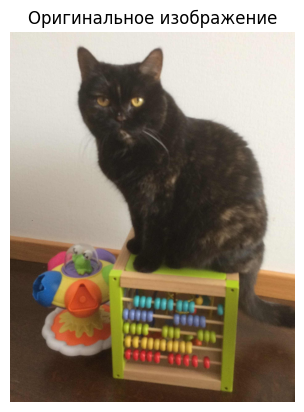

In [4]:
img = cv2.imread('cat.jpg')
draw_picture(img, 'Оригинальное изображение', bgr=True)
img.shape

## KMeans

Не будем применять масштабирование, единицы измерения (значения r/g/b) в одном масштабе

Подобие после преобразования KMeans (кластеров: 2) равно: ssim = 0.7463226887281257
Подобие после преобразования KMeans (кластеров: 5) равно: ssim = 0.790577850346262
Подобие после преобразования KMeans (кластеров: 10) равно: ssim = 0.817917393957162
Подобие после преобразования KMeans (кластеров: 20) равно: ssim = 0.8434981826173832


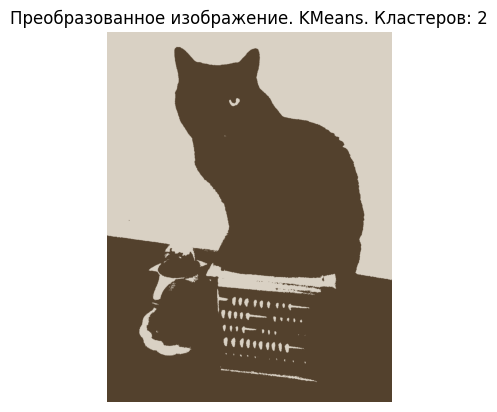

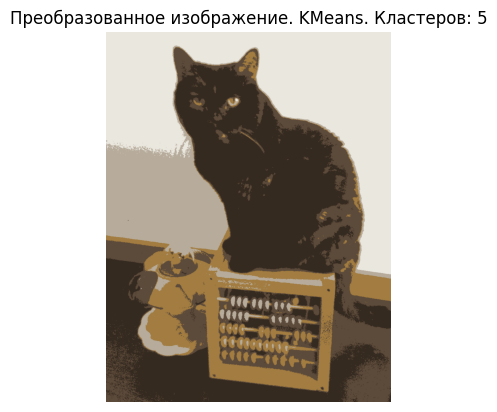

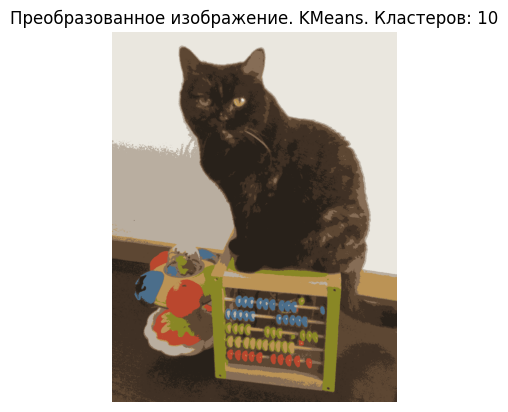

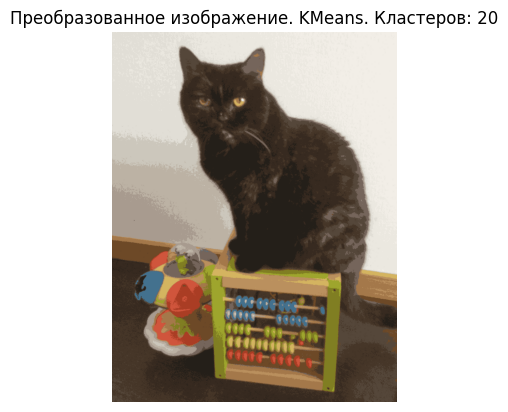

In [5]:
def modify_with_KMeans(original_img, clusters_count):
    flattened_image = flat_img(original_img)
    clf_kmeans = KMeans(n_clusters=clusters_count)
    cluster_vals = clf_kmeans.fit_predict(flattened_image)
    apply_clustering(flattened_image, cluster_vals, clusters_count)
    return unflat_img(flattened_image, original_img.shape)

kmean_clusters = [2, 5, 10, 20]

for clusters_count in kmean_clusters:
    modified_image = modify_with_KMeans(img, clusters_count)
    draw_picture(modified_image, 'Преобразованное изображение. KMeans. Кластеров: {}'.format(clusters_count), bgr=True)
    similarity = ssim(img, modified_image, data_range = img.max() - img.min(), channel_axis = 2)
    print("Подобие после преобразования KMeans (кластеров: {}) равно: ssim = {}".format(clusters_count, similarity))


## DBSCAN

In [6]:
# Для выполнения кластеризации с помощью DBSCAN пришлось уменьшить изображение
img_shape_DBSCAN = (int(img.shape[1]/2), int(img.shape[0]/2)) 
img_2 = cv2.resize(img, img_shape_DBSCAN, interpolation=cv2.INTER_LINEAR)
flattened_image = flat_img(img_2)
clf_DBSCAN = DBSCAN(eps = 1, min_samples=3)
DBSCAN_cluster_vals = np.array(clf_DBSCAN.fit_predict(flattened_image))

Подобие после преобразования DBSCAN (кластеров: 3406) равно: ssim = 0.6795593917113679


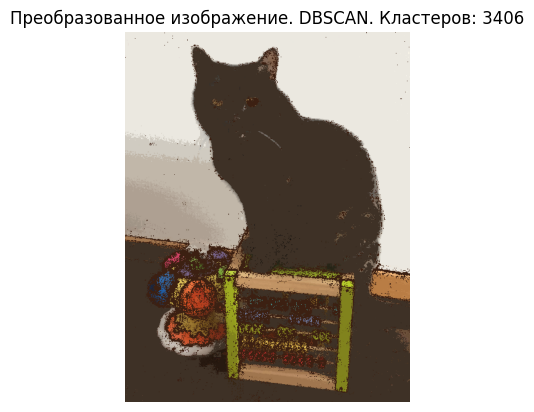

In [7]:
DBSCAN_cluster_count = DBSCAN_cluster_vals.max() + 1 # Do not consider -1 noise cluster
apply_clustering(flattened_image, DBSCAN_cluster_vals, clusters_count=DBSCAN_cluster_count)
modified_image_DBSCAN = unflat_img(flattened_image, img_2.shape)
draw_picture(modified_image_DBSCAN, 'Преобразованное изображение. DBSCAN. Кластеров: {}'.format(DBSCAN_cluster_count), bgr=True)
similarity_DBSCAN = ssim(img_2, modified_image_DBSCAN, data_range = img_2.max() - img_2.min(), channel_axis = 2)
print("Подобие после преобразования DBSCAN (кластеров: {}) равно: ssim = {}".format(DBSCAN_cluster_count, similarity_DBSCAN))

### AgglomerativeClustering

Подобие после преобразования KMeans (кластеров: 2) равно: ssim = 0.638050904575075
Подобие после преобразования KMeans (кластеров: 5) равно: ssim = 0.7927098526905453
Подобие после преобразования KMeans (кластеров: 10) равно: ssim = 0.8351563173557702
Подобие после преобразования KMeans (кластеров: 20) равно: ssim = 0.8945547839968158


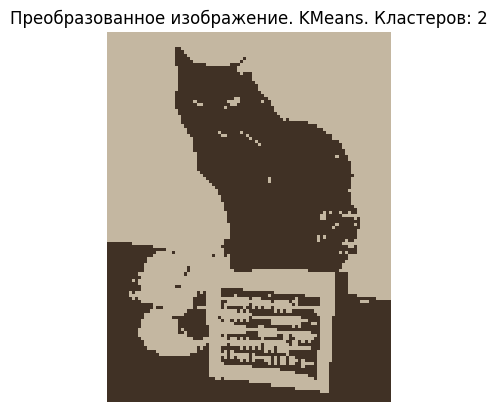

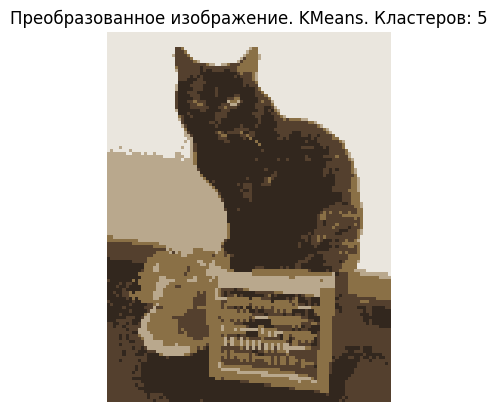

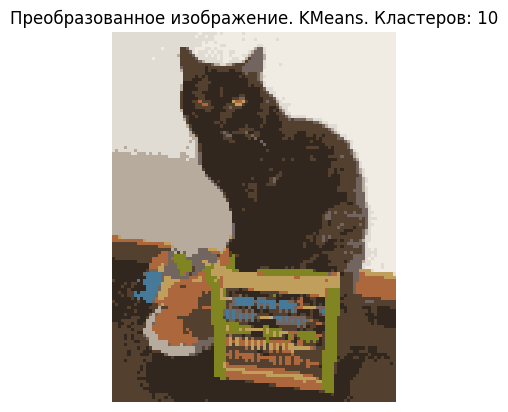

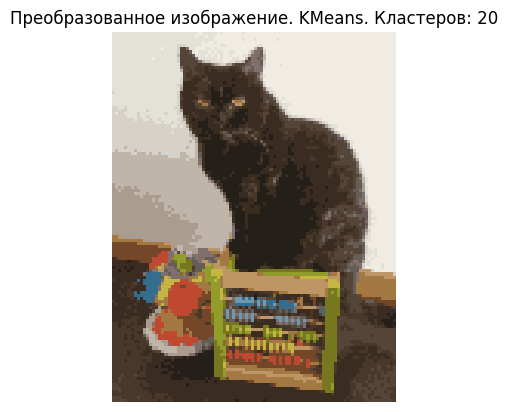

In [8]:
# Для выполнения кластеризации с помощью AgglomerativeClustering пришлось еще больше уменьшить изображение
img_shape_AC = (int(img.shape[1]/10), int(img.shape[0]/10)) 
# После проблем с долгим DBSCAN решил уменьшить изображение
img_10 = cv2.resize(img, img_shape_AC, interpolation=cv2.INTER_LINEAR)

def modify_with_AC(original_img, clusters_count):
    flattened_image = flat_img(original_img)
    clf_AC = AgglomerativeClustering(n_clusters=clusters_count)
    cluster_vals = clf_AC.fit_predict(flattened_image)
    apply_clustering(flattened_image, cluster_vals, clusters_count)
    return unflat_img(flattened_image, original_img.shape)

AC_clusters = [2, 5, 10, 20]

for clusters_count in AC_clusters:
    modified_image = modify_with_AC(img_10, clusters_count)
    draw_picture(modified_image, 'Преобразованное изображение. KMeans. Кластеров: {}'.format(clusters_count), bgr=True)
    similarity = ssim(img_10, modified_image, data_range = img_10.max() - img_10.min(), channel_axis = 2)
    print("Подобие после преобразования KMeans (кластеров: {}) равно: ssim = {}".format(clusters_count, similarity))